In [ ]:
# Comedy Genre Analysis Over Time (1990-2020)
# Percentage of anime with "Comedy" genre by year

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from collections import defaultdict
import numpy as np
from scipy import stats

In [ ]:
# AniList API endpoint
ANILIST_URL = 'https://graphql.anilist.co'

def query_anilist(query, variables=None):
    """Make a GraphQL request to AniList API with error handling"""
    response = requests.post(
        ANILIST_URL,
        json={'query': query, 'variables': variables or {}},
        headers={'Content-Type': 'application/json'}
    )
    
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:
        print(f"Rate limited! Waiting 60 seconds...")
        time.sleep(60)  # Wait a full minute if rate limited
        # Try again after waiting
        return query_anilist(query, variables)
    else:
        print(f"Error: {response.status_code}")
        return None

def get_anime_by_year(year, page=1):
    """Query AniList for all anime starting in a specific year."""
    query = '''
    query ($start: FuzzyDateInt, $end: FuzzyDateInt, $page: Int) {
        Page(page: $page, perPage: 50) {
            pageInfo {
                hasNextPage
            }
            media(startDate_greater: $start, startDate_lesser: $end, type: ANIME) {
                id
                title { romaji }
                genres
                format
                startDate { year month day }
            }
        }
    }
    '''
    
    # FuzzyDateInt format: YYYYMMDD (use 0 for missing month/day)
    start = int(f"{year}0000")
    end = int(f"{year}1232")  # 32 to include all of December
    variables = {'start': start, 'end': end, 'page': page}
    result = query_anilist(query, variables)
    
    if result and 'data' in result:
        return result['data']['Page']
    return None

def collect_all_anime_for_year(year):
    """Collect all anime for a given year (handles pagination)"""
    all_anime = []
    page = 1
    
    print(f"Collecting anime for {year}...", end=" ")
    
    while True:
        # Wait longer between requests to avoid rate limiting
        time.sleep(1.0)  # 1 second between requests = max 60 requests/minute
        
        data = get_anime_by_year(year, page)
        
        if not data or not data['media']:
            break
            
        all_anime.extend(data['media'])
        
        if not data['pageInfo']['hasNextPage']:
            break
            
        page += 1
    
    print(f"Found {len(all_anime)} anime")
    return all_anime

def analyze_genre_trend(target_genre="Comedy", start_year=1990, end_year=2020):
    """Analyze any genre percentage over time"""
    
    results = []
    
    for year in range(start_year, end_year + 1):
        # Get all anime for this year
        anime_list = collect_all_anime_for_year(year)
        
        if not anime_list:
            print(f"No data for {year}, skipping...")
            continue
        
        # Count total anime and target genre anime
        total_anime = len(anime_list)
        genre_anime = 0
        
        for anime in anime_list:
            if anime['genres'] and target_genre in anime['genres']:
                genre_anime += 1
        
        # Calculate percentage
        genre_percentage = (genre_anime / total_anime * 100) if total_anime > 0 else 0
        
        results.append({
            'year': year,
            'total_anime': total_anime,
            f'{target_genre.lower()}_anime': genre_anime,
            f'{target_genre.lower()}_percentage': genre_percentage
        })
        
        print(f"{year}: {genre_anime}/{total_anime} = {genre_percentage:.1f}% {target_genre}")
        
        # Be respectful to the API - wait longer between years
        time.sleep(2.0)  # 2 seconds between years
    
    return pd.DataFrame(results)

def analyze_multiple_genres_trend(genres_list=["Comedy", "Action", "Romance"], start_year=1990, end_year=2020):
    """Analyze multiple genres at once - MOST EFFICIENT for multiple genres"""
    
    results = []
    
    for year in range(start_year, end_year + 1):
        # Get all anime for this year (only one API call per year!)
        anime_list = collect_all_anime_for_year(year)
        
        if not anime_list:
            print(f"No data for {year}, skipping...")
            continue
        
        anime_list = [anime for anime in anime_list if anime.get('genres') and len(anime['genres']) > 0]

        # Check average genres per anime for this year
        if anime_list:
            avg_genres = sum(len(anime['genres']) for anime in anime_list) / len(anime_list)
            print(f"  {year}: {len(anime_list)} anime, avg {avg_genres:.2f} genres per anime")


        # Count total anime
        total_anime = len(anime_list)
        
        # Count each genre
        genre_counts = {genre: 0 for genre in genres_list}
        
        for anime in anime_list:
            if anime['genres']:
                for genre in genres_list:
                    if genre in anime['genres']:
                        genre_counts[genre] += 1
        
        # Calculate percentages and store results
        year_data = {'year': year, 'total_anime': total_anime}
        
        for genre in genres_list:
            count = genre_counts[genre]
            percentage = (count / total_anime * 100) if total_anime > 0 else 0
            year_data[f'{genre.lower()}_anime'] = count
            year_data[f'{genre.lower()}_percentage'] = percentage
        
        results.append(year_data)
        
        # Print summary for this year
        genre_summary = ", ".join([f"{genre_counts[g]} {g}" for g in genres_list])
        print(f"{year}: {genre_summary} out of {total_anime} total")
        
        # Be respectful to the API
        time.sleep(2.0)
    
    return pd.DataFrame(results)

def plot_genre_trend(df, genre="Comedy"):
    """Create visualization for any genre"""
    genre_col = f'{genre.lower()}_percentage'
    
    plt.figure(figsize=(12, 8))
    
    # Main line plot
    plt.plot(df['year'], df[genre_col], 
             marker='o', linewidth=2, markersize=6, color='#ff6b6b')
    
    # Formatting
    plt.title(f'Percentage of Anime with {genre} Genre Over Time', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(f'Percentage of Anime with {genre} Genre (%)', fontsize=12)
    
    # Grid and styling
    plt.grid(True, alpha=0.3)
    plt.xticks(range(df['year'].min(), df['year'].max() + 1, 5), rotation=45)
    plt.ylim(0, max(df[genre_col]) * 1.1)
    
    # Add trend line
    import numpy as np
    z = np.polyfit(df['year'], df[genre_col], 1)
    p = np.poly1d(z)
    plt.plot(df['year'], p(df['year']), "--", alpha=0.7, color='gray',
             label=f'Trend line (slope: {z[0]:.2f}% per year)')
    
    # Annotations for interesting points
    max_idx = df[genre_col].idxmax()
    min_idx = df[genre_col].idxmin()
    
    plt.annotate(f'Peak: {df.loc[max_idx, genre_col]:.1f}%', 
                xy=(df.loc[max_idx, 'year'], df.loc[max_idx, genre_col]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return plt

def plot_multiple_genres(df, genres_list=["Comedy", "Action", "Romance"], start_year=None, end_year=None):
    """Plot multiple genres in separate subplots with filled area charts"""
    import math
    
    # Filter by years if specified
    filtered_df = df.copy()
    if start_year is not None:
        filtered_df = filtered_df[filtered_df['year'] >= start_year]
    if end_year is not None:
        filtered_df = filtered_df[filtered_df['year'] <= end_year]
    
    if filtered_df.empty:
        print("No data available for the specified year range")
        return None
    
    # Calculate subplot layout
    n_genres = len(genres_list)
    n_cols = 3  # 3 columns
    n_rows = math.ceil(n_genres / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    
    # Handle case where there's only one row
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#feca57', '#ff9ff3']
    
    for i, genre in enumerate(genres_list):
        genre_col = f'{genre.lower()}_percentage'
        
        if genre_col in filtered_df.columns:
            ax = axes[i]
            
            # Create filled area plot (no markers, filled area)
            ax.fill_between(filtered_df['year'], filtered_df[genre_col], 
                           color=colors[i % len(colors)], alpha=0.7)
            
            # Add a clean line on top (no markers)
            ax.plot(filtered_df['year'], filtered_df[genre_col], 
                   linewidth=2, color=colors[i % len(colors)], alpha=0.9)
            
            # Formatting for each subplot
            ax.set_title(f'{genre}', fontweight='bold')
            ax.set_xlabel('Year')
            ax.set_ylabel('Percentage (%)')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            
            # Set consistent y-axis limits across all subplots
            ax.set_ylim(0, filtered_df[[col for col in filtered_df.columns if col.endswith('_percentage')]].max().max() * 1.1)
            
            # Set x-axis to show all years in range
            ax.set_xlim(filtered_df['year'].min() - 0.5, filtered_df['year'].max() + 0.5)
    
    # Hide empty subplots
    for i in range(n_genres, len(axes)):
        axes[i].set_visible(False)
    
    # Create title with year range info
    year_range = f"{filtered_df['year'].min()}-{filtered_df['year'].max()}"
    main_title = f'Anime Genre Trends Over Time ({year_range})'
    
    plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)  # Make room for main title
    plt.show()
    
    print(f"Plotted data for years {filtered_df['year'].min()} to {filtered_df['year'].max()}")
    
    return fig

def plot_comedy_trend(df):
    """Create the visualization for comedy data"""
    return plot_genre_trend(df, "Comedy")

def print_summary_stats(df):
    """Print some interesting statistics"""
    print("\n" + "="*50)
    print("COMEDY GENRE ANALYSIS SUMMARY")
    print("="*50)
    
    print(f"Time period analyzed: {df['year'].min()} - {df['year'].max()}")
    print(f"Total years with data: {len(df)}")
    print(f"Average comedy percentage: {df['comedy_percentage'].mean():.1f}%")
    
    max_year = df.loc[df['comedy_percentage'].idxmax()]
    min_year = df.loc[df['comedy_percentage'].idxmin()]
    
    print(f"\nHighest comedy percentage: {max_year['comedy_percentage']:.1f}% in {max_year['year']}")
    print(f"Lowest comedy percentage: {min_year['comedy_percentage']:.1f}% in {min_year['year']}")
    
    # Calculate trend
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['year'], df['comedy_percentage'])
    
    print(f"\nTrend analysis:")
    print(f"Slope: {slope:.3f}% per year")
    print(f"R-squared: {r_value**2:.3f}")
    
    if slope > 0:
        print("📈 Comedy anime percentage is trending UPWARD over time")
    else:
        print("📉 Comedy anime percentage is trending DOWNWARD over time")

def save_genre_csvs(df, genres_list, filename_prefix="anime_genre_analysis"):
    """Save separate CSV files for each genre to ../genre_data/ folder"""
    
    # Create the output directory
    output_dir = os.path.join("..", "genre_data")
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Created/using directory: {output_dir}")
    
    # Create a master file with all data
    master_file = os.path.join(output_dir, f'{filename_prefix}_all_genres.csv')
    df.to_csv(master_file, index=False)
    print(f"✅ Saved master file: {master_file}")
    
    # Create individual files for each genre
    for genre in genres_list:
        genre_col_anime = f'{genre.lower()}_anime'
        genre_col_percentage = f'{genre.lower()}_percentage'
        
        if genre_col_percentage in df.columns:
            # Create a clean DataFrame for this genre
            genre_df = df[['year', 'total_anime', genre_col_anime, genre_col_percentage]].copy()
            
            # Rename columns for clarity
            genre_df = genre_df.rename(columns={
                genre_col_anime: f'{genre}_anime_count',
                genre_col_percentage: f'{genre}_percentage'
            })
            
            # Save individual CSV to the genre_data folder
            filename = f'{filename_prefix}_{genre.lower().replace(" ", "_")}.csv'
            filepath = os.path.join(output_dir, filename)
            genre_df.to_csv(filepath, index=False)
            print(f"✅ Saved {genre} data: {filepath}")
    
    print(f"\n📊 Summary: Created {len(genres_list) + 1} CSV files in {output_dir}")
    return output_dir

In [ ]:
start_year = 1963
end_year = 2024

# Popular genres to analyze
popular_genres = ["Action", "Adventure", "Comedy", "Drama", "Ecchi", "Fantasy", "Horror", "Mahou Shoujo", "Mecha", "Music", "Mystery", "Psychological", "Romance", "Sci-Fi", "Slice of Life", "Sports", "Supernatural", "Thriller"]

# Uncomment below for full analysis (takes 45-60 minutes)
print(f"Starting full analysis ({start_year}-{end_year})...")
print("This will take 45-60 minutes due to API rate limiting...")

# Get all data
full_data = analyze_multiple_genres_trend(popular_genres, start_year, end_year)

# Save to CSV files in ../genre_data/ folder
output_folder = save_genre_csvs(full_data, popular_genres, f"anime_genre_analysis_{start_year}_{end_year}")

# Create visualization

print(f"Analysis complete! Check your CSV files in: {output_folder}")

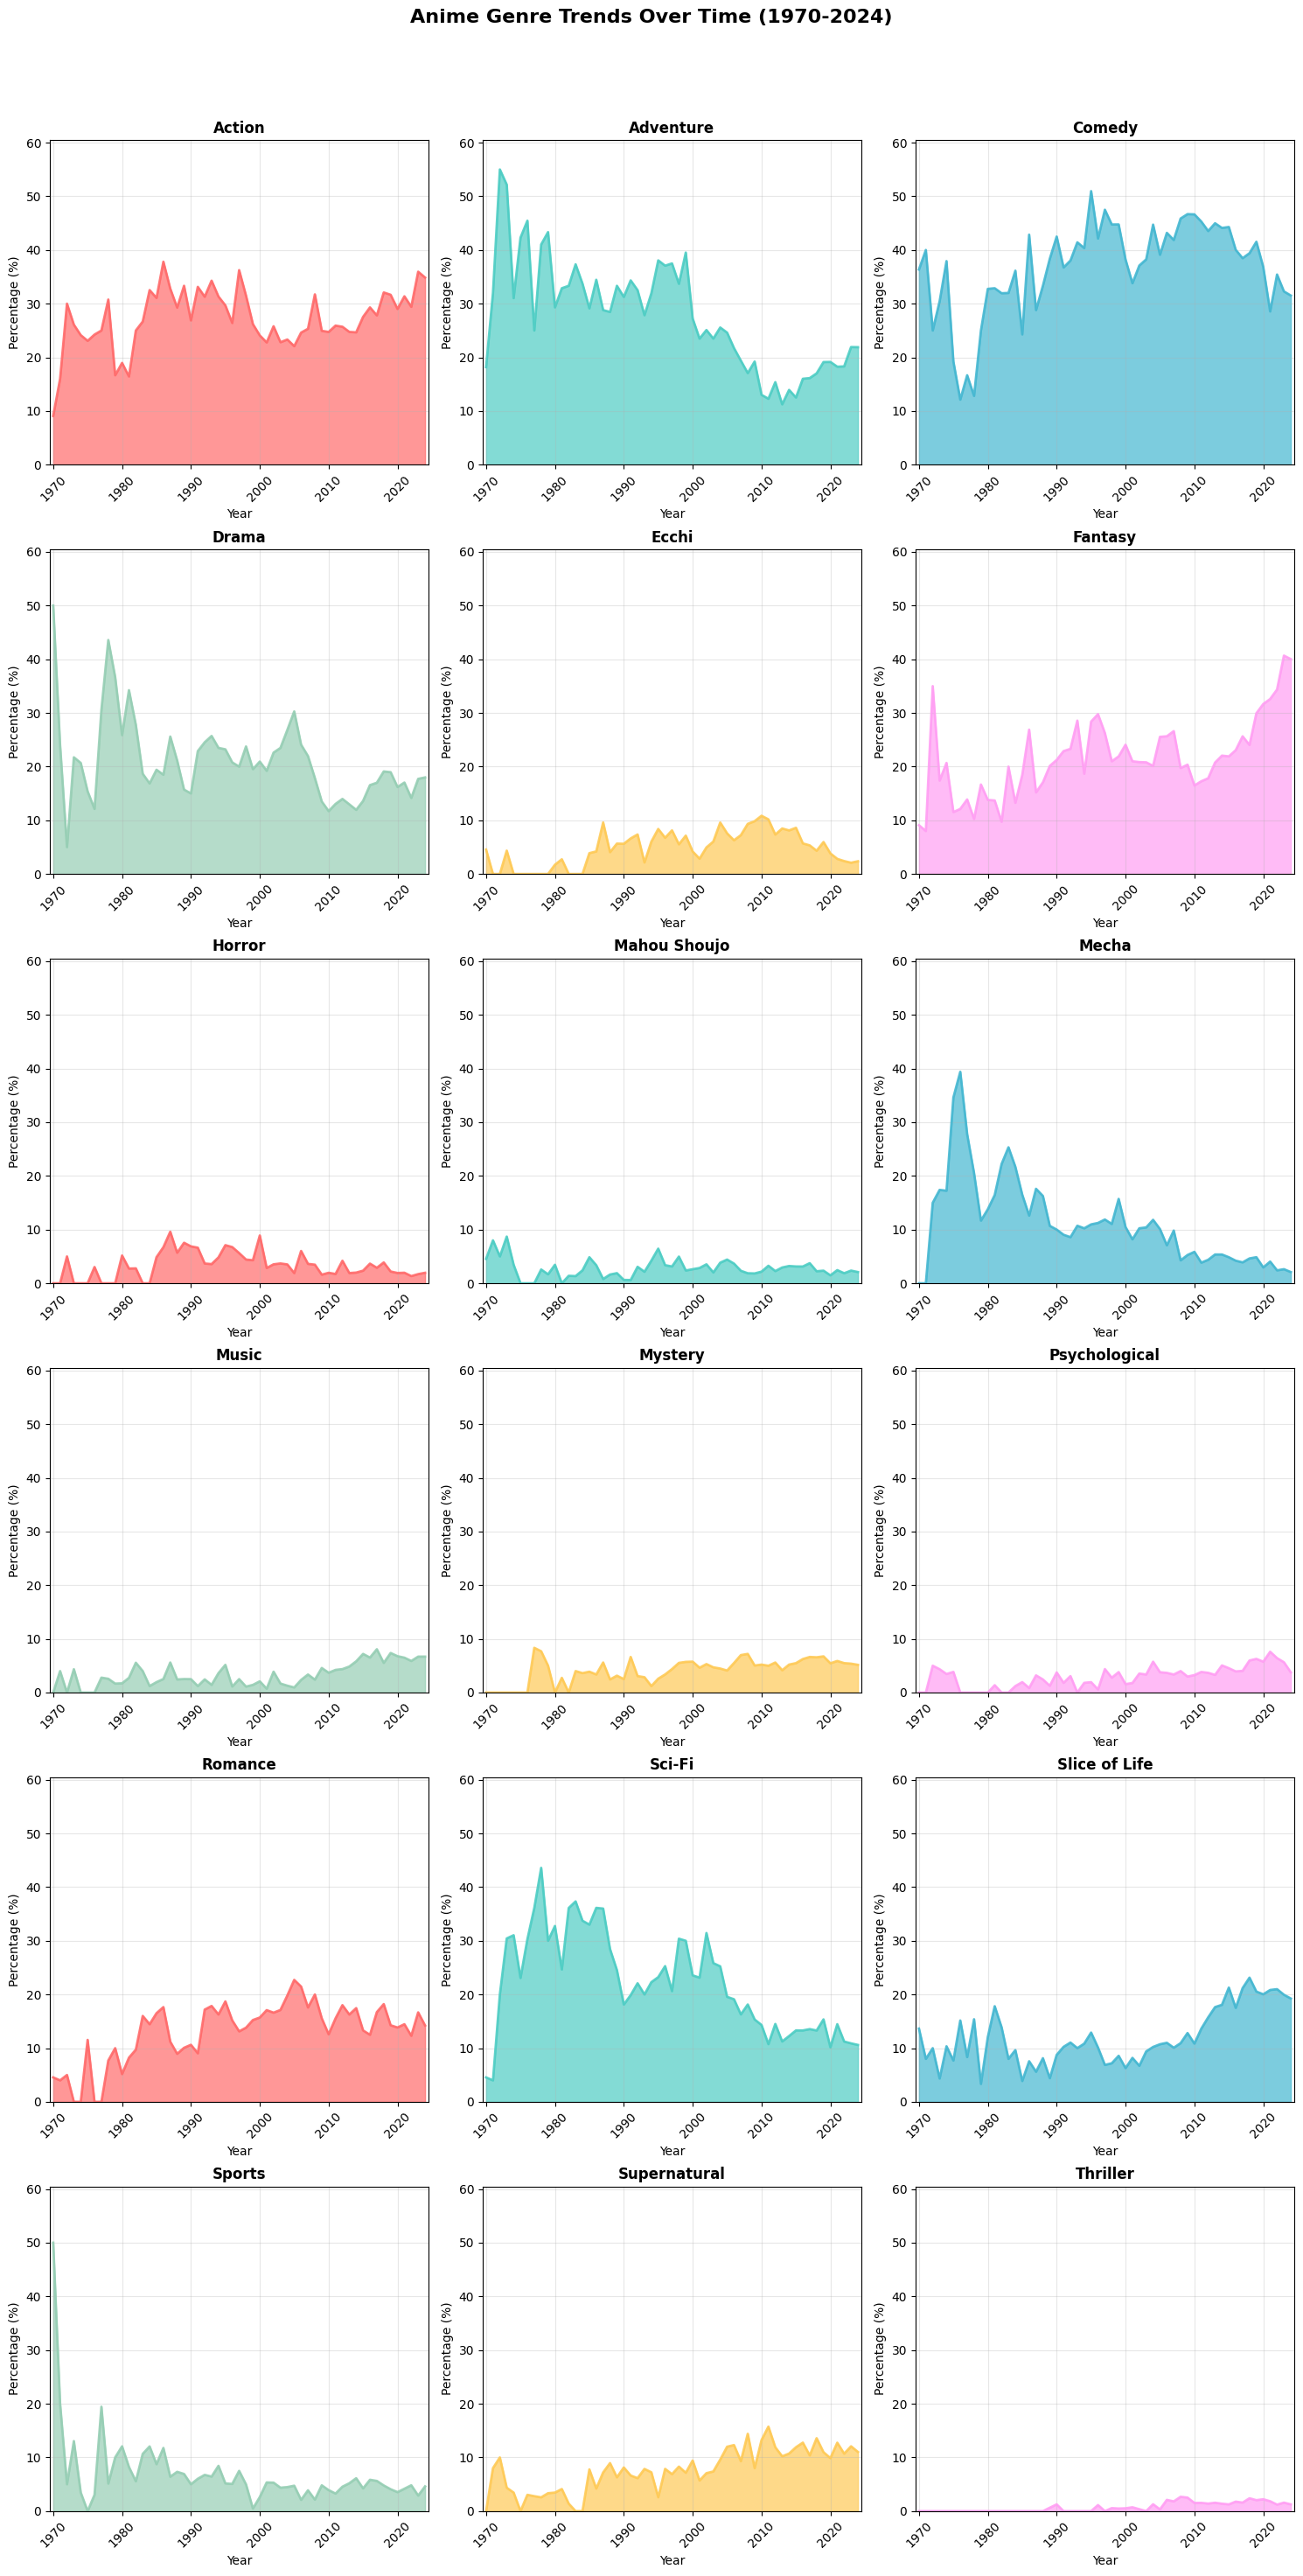

Plotted data for years 1970 to 2024
lol


In [19]:
plot_multiple_genres(full_data, popular_genres, start_year=1970)
print("lol")

In [ ]:
plot_multiple_genres(df, popular_genres)
save_genre_csvs(df, popular_genres)

In [ ]:
def analyze_genre_counts_per_year(start_year=1990, end_year=2020):
    """Analyze average number of genres per anime by year to detect data quality issues"""
    
    results = []
    
    for year in range(start_year, end_year + 1):
        # Get all anime for this year
        anime_list = collect_all_anime_for_year(year)
        
        if not anime_list:
            print(f"No data for {year}, skipping...")
            continue
        
        # Analyze genre counts
        total_anime = len(anime_list)
        anime_with_no_genres = 0
        anime_with_genres = 0
        total_genre_count = 0
        genre_counts = []
        
        for anime in anime_list:
            if not anime['genres'] or len(anime['genres']) == 0:
                anime_with_no_genres += 1
                genre_counts.append(0)
            else:
                num_genres = len(anime['genres'])
                anime_with_genres += 1
                total_genre_count += num_genres
                genre_counts.append(num_genres)
        
        # Calculate statistics
        avg_genres_per_anime = total_genre_count / total_anime if total_anime > 0 else 0
        avg_genres_excluding_zero = total_genre_count / anime_with_genres if anime_with_genres > 0 else 0
        percentage_no_genres = (anime_with_no_genres / total_anime * 100) if total_anime > 0 else 0
        
        results.append({
            'year': year,
            'total_anime': total_anime,
            'anime_with_genres': anime_with_genres,
            'anime_with_no_genres': anime_with_no_genres,
            'percentage_no_genres': percentage_no_genres,
            'avg_genres_per_anime': avg_genres_per_anime,
            'avg_genres_excluding_zero': avg_genres_excluding_zero,
            'max_genres': max(genre_counts) if genre_counts else 0,
            'min_genres': min(genre_counts) if genre_counts else 0
        })
        
        print(f"{year}: {total_anime} anime, {anime_with_no_genres} with no genres ({percentage_no_genres:.1f}%), avg genres: {avg_genres_per_anime:.2f}")
        
        # Be respectful to the API
        time.sleep(2.0)
    
    return pd.DataFrame(results)

def plot_genre_count_analysis(df):
    """Plot genre count statistics to identify data quality issues"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Average genres per anime over time
    ax1.plot(df['year'], df['avg_genres_per_anime'], marker='o', linewidth=2, color='blue')
    ax1.set_title('Average Number of Genres per Anime Over Time')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Genres per Anime')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Percentage of anime with no genres
    ax2.plot(df['year'], df['percentage_no_genres'], marker='o', linewidth=2, color='red')
    ax2.set_title('Percentage of Anime with No Genres')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Percentage (%)')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    # Plot 3: Total anime count per year
    ax3.bar(df['year'], df['total_anime'], alpha=0.7, color='green')
    ax3.set_title('Total Anime Count per Year')
    ax3.set_xlabel('Year')
    ax3.set_ylabel('Number of Anime')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    # Plot 4: Max genres per anime per year
    ax4.plot(df['year'], df['max_genres'], marker='o', linewidth=2, color='purple', label='Max genres')
    ax4.plot(df['year'], df['avg_genres_excluding_zero'], marker='s', linewidth=2, color='orange', label='Avg (excluding zero)')
    ax4.set_title('Genre Count Statistics')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Number of Genres')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def find_problematic_years(df, threshold_no_genres=50):
    """Identify years with potential data quality issues"""
    print("=== DATA QUALITY ANALYSIS ===")
    
    # Years with high percentage of anime with no genres
    high_no_genres = df[df['percentage_no_genres'] > threshold_no_genres]
    if not high_no_genres.empty:
        print(f"\n⚠️  Years with >{threshold_no_genres}% anime having no genres:")
        for _, row in high_no_genres.iterrows():
            print(f"  {row['year']}: {row['percentage_no_genres']:.1f}% ({row['anime_with_no_genres']}/{row['total_anime']})")
    
    # Years with very low average genres
    low_avg_genres = df[df['avg_genres_per_anime'] < 1.0]
    if not low_avg_genres.empty:
        print(f"\n⚠️  Years with <1.0 average genres per anime:")
        for _, row in low_avg_genres.iterrows():
            print(f"  {row['year']}: {row['avg_genres_per_anime']:.2f} avg genres")
    
    # Years with suspiciously low anime counts
    median_count = df['total_anime'].median()
    low_count_threshold = median_count * 0.3  # Less than 30% of median
    low_counts = df[df['total_anime'] < low_count_threshold]
    if not low_counts.empty:
        print(f"\n⚠️  Years with suspiciously low anime counts (<{low_count_threshold:.0f}):")
        for _, row in low_counts.iterrows():
            print(f"  {row['year']}: {row['total_anime']} anime")
    
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  Average anime per year: {df['total_anime'].mean():.1f}")
    print(f"  Average genres per anime (overall): {df['avg_genres_per_anime'].mean():.2f}")
    print(f"  Average % with no genres: {df['percentage_no_genres'].mean():.1f}%")
    
    return {
        'high_no_genres': high_no_genres,
        'low_avg_genres': low_avg_genres, 
        'low_counts': low_counts
    }

In [ ]:
genre_counts_df = analyze_genre_counts_per_year(start_year, end_year)
fig = plot_genre_count_analysis(genre_counts_df)

In [ ]:
find_problematic_years(genre_counts_df)